# Week 7 — Day 2: Building CNNs & Transfer Learning

Today, we will:
- Build a CNN from scratch.
- Apply data augmentation to reduce overfitting.
- Use transfer learning with MobileNetV2.
- Compare accuracy and training time.

## Import Libraries

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout,RandomFlip,RandomRotation,RandomZoom)
from tensorflow.keras.applications import MobileNetV2

In [3]:
DATA_DIR = "/content/melanoma_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Train directory: /content/melanoma_dataset/train
Test directory: /content/melanoma_dataset/test


## Load the Dataset

In [13]:
from google.colab import files
uploaded = files.upload()

Saving Skin_Cancer_Dataset.zip to Skin_Cancer_Dataset.zip


In [14]:
import zipfile
import os

zip_files = [
    f for f in uploaded.keys()
    if f.lower().endswith(".zip")
]

if not zip_files:
    raise FileNotFoundError("No ZIP file was uploaded.")

zip_path = zip_files[0]

extract_path = "/content/melanoma_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:")
print(extract_path)

Dataset extracted to:
/content/melanoma_dataset


In [15]:
DATA_DIR = "/content/melanoma_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

TRAIN_DIR: /content/melanoma_dataset/train
TEST_DIR: /content/melanoma_dataset/test
Train exists: True
Test exists: True


In [16]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.


In [17]:
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Benign', 'Malignant']
Number of classes: 2


### Image size and batch settings

In [18]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (128, 128)
Batch size: 32


### Loading Training and Validation Data

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR,validation_split=0.2,subset="training",seed=SEED,image_size=IMG_SIZE,batch_size=BATCH_SIZE,label_mode="int")
val_ds = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR,validation_split=0.2,subset="validation",seed=SEED,image_size=IMG_SIZE,batch_size=BATCH_SIZE,label_mode="int")
test_ds = tf.keras.utils.image_dataset_from_directory(TEST_DIR,image_size=IMG_SIZE,batch_size=BATCH_SIZE,shuffle=False,label_mode="int")

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.


### Class Names

In [20]:
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Benign', 'Malignant']
Number of classes: 2


### Improving pipeline speed

In [21]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Let's look at the photos.

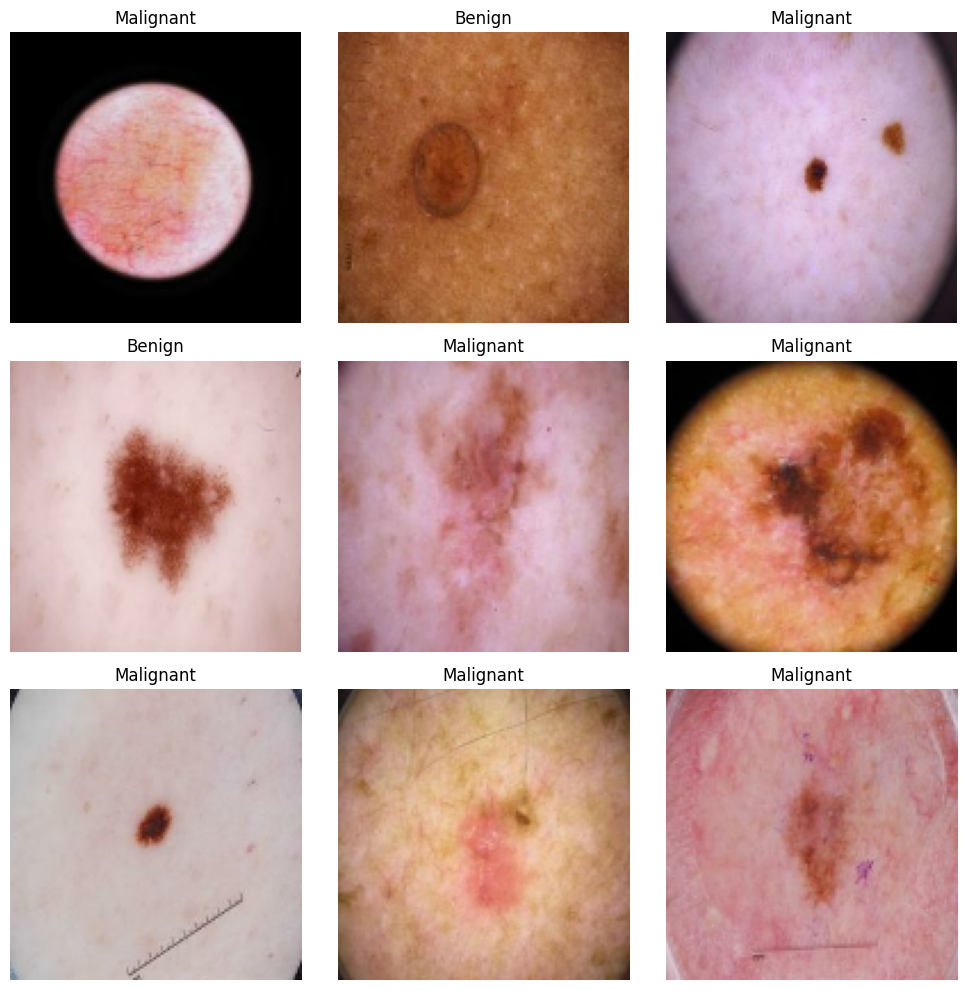

In [27]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## CNN From Scratch
### Build CNN

In [24]:
model_cnn = Sequential([
    Conv2D(32,(3, 3),activation="relu",input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64,(3, 3),activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,986 (14.14 MB)

 Trainable params: 3,705,986 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [25]:
model_cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### Train CNN

In [26]:
start_time = time.time()
history_cnn = model_cnn.fit(train_ds,validation_data=val_ds,epochs=10)
cnn_training_time = time.time() - start_time
print(f"CNN training time: {cnn_training_time:.2f} seconds")

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.5456 - loss: 27.0005 - val_accuracy: 0.5179 - val_loss: 0.6926
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 285s 957ms/step - accuracy: 0.5323 - loss: 0.6915 - val_accuracy: 0.5179 - val_loss: 0.6926
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 258s 869ms/step - accuracy: 0.5323 - loss: 0.6911 - val_accuracy: 0.5179 - val_loss: 0.6928
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 247s 833ms/step - accuracy: 0.5323 - loss: 0.6911 - val_accuracy: 0.5179 - val_loss: 0.6929
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 241s 811ms/step - accuracy: 0.5323 - loss: 0.6911 - val_accuracy: 0.5179 - val_loss: 0.6929
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 259s 800ms/step - accuracy: 0.5323 - loss: 0.6911 - val_accuracy: 0.5179 - val_loss: 0.6929
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 265s 810ms/step - accuracy: 0.5323 - loss: 0.6911 - val_accuracy: 0.5179 - val_loss: 0.6929
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 246s 829ms/step - accuracy: 0.5323 - l

### Evaluate CNN

In [28]:
cnn_test_loss, cnn_test_accuracy = model_cnn.evaluate(test_ds)
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.5000 - loss: 0.6951
CNN Test Loss: 0.6951
CNN Test Accuracy: 0.5000


### CNN Curves

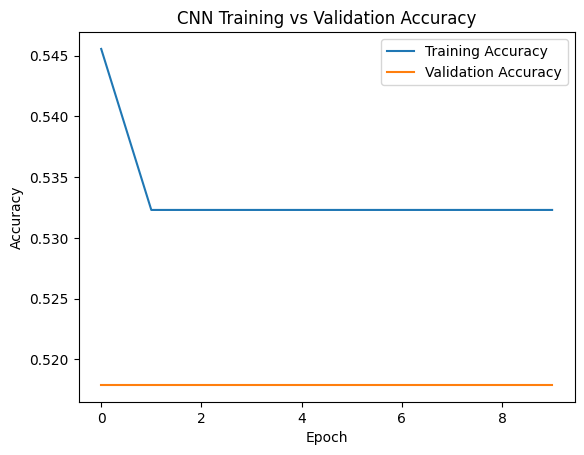

In [29]:
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

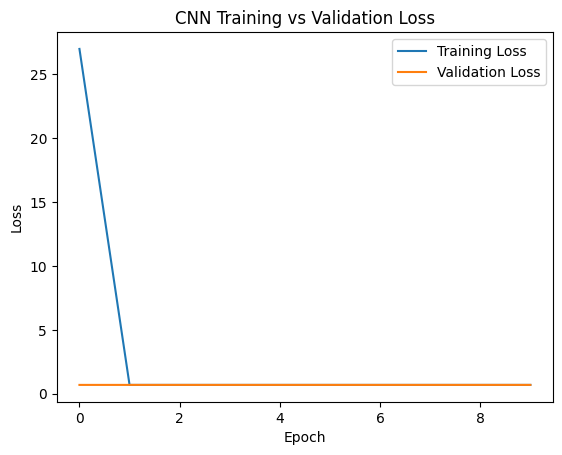

In [30]:
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

## CNN From Scratch — Observation
The CNN was trained from scratch using the melanoma skin lesion dataset.
The model uses convolutional and pooling layers to extract visual features,
followed by dense layers for binary classification.
The test accuracy and training time were recorded as a baseline for comparison
with data augmentation and transfer learning.

## Data Augmentation

In [31]:
data_augmentation = Sequential([RandomFlip("horizontal"),RandomRotation(0.1),RandomZoom(0.1)])

### Let's look at the augmentation.

This cell is important because it lets you see what augmentation has been done.

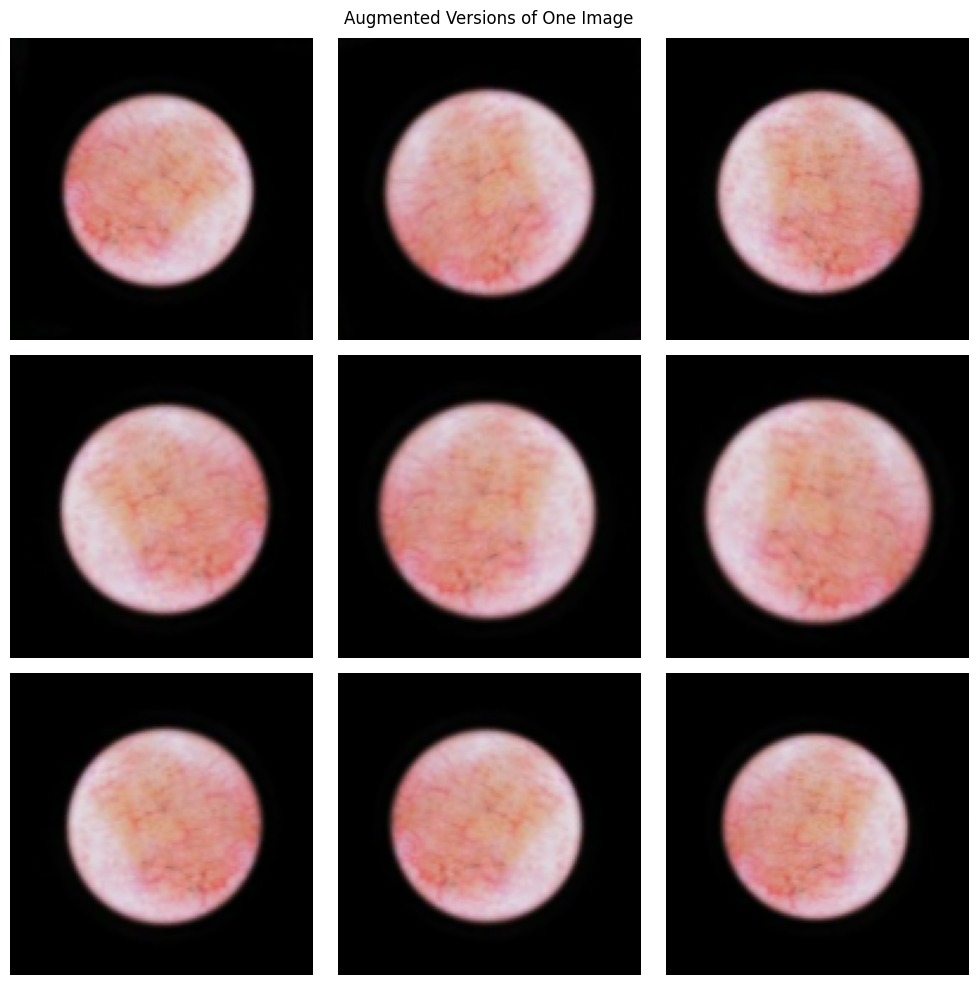

In [32]:
for images, labels in train_ds.take(1):
    sample_image = images[0]
    break

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(
        tf.clip_by_value(augmented_image[0], 0, 255).numpy().astype("uint8")
    )
    plt.axis("off")

plt.suptitle("Augmented Versions of One Image")
plt.tight_layout()
plt.show()

### CNN + Augmentation

In [33]:
model_aug = Sequential([
    data_augmentation,
    Conv2D(32,(3, 3),activation="relu",input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),MaxPooling2D((2, 2)),Conv2D(64,(3, 3),activation="relu"),MaxPooling2D((2, 2)),Flatten(),Dense(64, activation="relu"),Dense(num_classes, activation="softmax")
    ])
model_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (1, 128, 128, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 126, 126, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 63, 63, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 61, 61, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 30, 30, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (1, 57600)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 64)                │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,986 (14.14 MB)

 Trainable params: 3,705,986 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [34]:
model_aug.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### Train

In [35]:
start_time = time.time()
history_aug = model_aug.fit(train_ds,validation_data=val_ds,epochs=10)
aug_training_time = time.time() - start_time
print(f"CNN + Augmentation training time: {aug_training_time:.2f} seconds")

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 279s 932ms/step - accuracy: 0.6720 - loss: 6.1560 - val_accuracy: 0.6526 - val_loss: 0.5972
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 933ms/step - accuracy: 0.6748 - loss: 0.5981 - val_accuracy: 0.6779 - val_loss: 0.5843
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 933ms/step - accuracy: 0.6852 - loss: 0.5907 - val_accuracy: 0.6728 - val_loss: 0.5876
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 934ms/step - accuracy: 0.6800 - loss: 0.6498 - val_accuracy: 0.7352 - val_loss: 0.5429
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 276s 930ms/step - accuracy: 0.7456 - loss: 0.5425 - val_accuracy: 0.7697 - val_loss: 0.4942
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 934ms/step - accuracy: 0.7642 - loss: 0.5033 - val_accuracy: 0.7213 - val_loss: 0.5383
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 278s 936ms/step - accuracy: 0.7700 - loss: 0.4982 - val_accuracy: 0.7819 - val_loss: 0.4730
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 934ms/step - accuracy: 0.7689 -

### Evaluate

In [36]:
aug_test_loss, aug_test_accuracy = model_aug.evaluate(test_ds)
print(f"CNN + Augmentation Test Loss: {aug_test_loss:.4f}")
print(f"CNN + Augmentation Test Accuracy: {aug_test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - accuracy: 0.7590 - loss: 0.5008
CNN + Augmentation Test Loss: 0.5008
CNN + Augmentation Test Accuracy: 0.7590


### Validation Accuracy Comparison

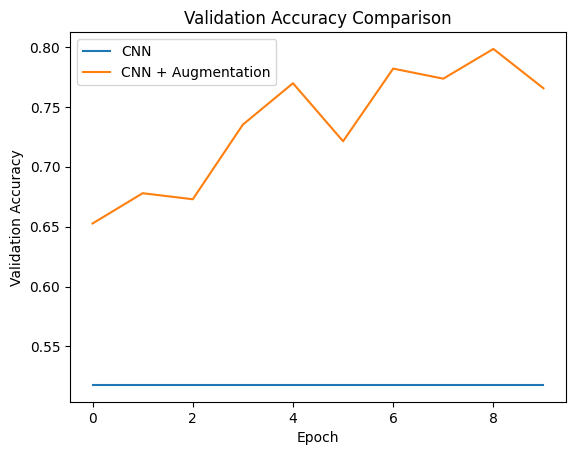

In [37]:

plt.plot(history_cnn.history["val_accuracy"],label="CNN")
plt.plot(history_aug.history["val_accuracy"],label="CNN + Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

## Data Augmentation — Observation

Data augmentation was added using random horizontal flips, rotations, and zooms.
The augmented CNN was compared with the original CNN using validation curves,
test accuracy, and training time.
The main goal was to determine whether augmentation improved generalization
and reduced signs of overfitting.

## Transfer Learning

### Load MobileNetV2

In [38]:
base_model = MobileNetV2(include_top=False,weights="imagenet",input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False
print("Base model layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model layers: 154
Trainable: False


### Build Transfer Learning Model

In [39]:
model_transfer = Sequential([
    base_model,

    Flatten(),

    Dense(64, activation="relu"),

    Dense(num_classes, activation="softmax")
])
model_transfer.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,310,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,568,898 (13.61 MB)

 Trainable params: 1,310,914 (5.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile

In [40]:
model_transfer.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### Train Transfer Learning

In [41]:
start_time = time.time()
history_transfer = model_transfer.fit(train_ds,validation_data=val_ds,epochs=10)
transfer_training_time = time.time() - start_time
print(
    f"MobileNetV2 training time: "
    f"{transfer_training_time} seconds"
)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 164s 531ms/step - accuracy: 0.7769 - loss: 0.6188 - val_accuracy: 0.8143 - val_loss: 0.4055
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 168s 564ms/step - accuracy: 0.8243 - loss: 0.3869 - val_accuracy: 0.8257 - val_loss: 0.3739
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 166s 561ms/step - accuracy: 0.8375 - loss: 0.3546 - val_accuracy: 0.8232 - val_loss: 0.3779
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 201s 559ms/step - accuracy: 0.8460 - loss: 0.3369 - val_accuracy: 0.8198 - val_loss: 0.3825
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 158s 532ms/step - accuracy: 0.8517 - loss: 0.3256 - val_accuracy: 0.8198 - val_loss: 0.3850
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 202s 531ms/step - accuracy: 0.8564 - loss: 0.3165 - val_accuracy: 0.8215 - val_loss: 0.3884
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 159s 536ms/step - accuracy: 0.8610 - loss: 0.3069 - val_accuracy: 0.8227 - val_loss: 0.3962
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 157s 530ms/step - accuracy: 0.8630 -

### Evaluate

In [42]:
transfer_test_loss, transfer_test_accuracy = model_transfer.evaluate(test_ds)
print(f"MobileNetV2 Test Loss: {transfer_test_loss}")
print(f"MobileNetV2 Test Accuracy: {transfer_test_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 418ms/step - accuracy: 0.7590 - loss: 0.5021
MobileNetV2 Test Loss: 0.502070963382721
MobileNetV2 Test Accuracy: 0.7590000033378601


### Transfer Learning Curves

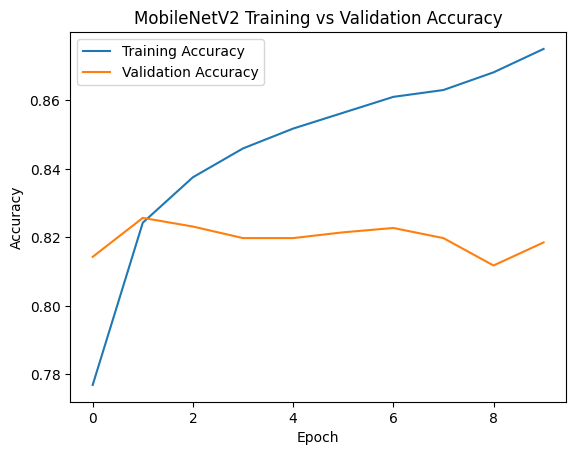

In [43]:
plt.plot(history_transfer.history["accuracy"],label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training vs Validation Accuracy")
plt.legend()
plt.show()

## Final Comparison
### Comparison Table

In [44]:
results = pd.DataFrame({
    "Model": [
        "CNN from Scratch",
        "CNN + Data Augmentation",
        "MobileNetV2 Transfer Learning"
    ],
    "Test Accuracy": [
        cnn_test_accuracy,
        aug_test_accuracy,
        transfer_test_accuracy
    ],
    "Training Time (seconds)": [
        cnn_training_time,
        aug_training_time,
        transfer_training_time
    ]
})

results

,Model,Test Accuracy,Training Time (seconds)
0,CNN from Scratch,0.500,2624.380385
1,CNN + Data Augmentation,0.759,2772.867829
2,MobileNetV2 Transfer Learning,0.759,1735.973474


### Accuracy Comparison

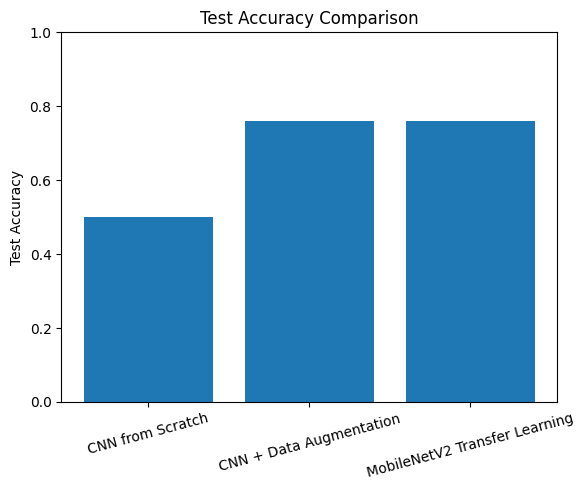

In [45]:

plt.bar(results["Model"],results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.show()

### Training Time Comparison

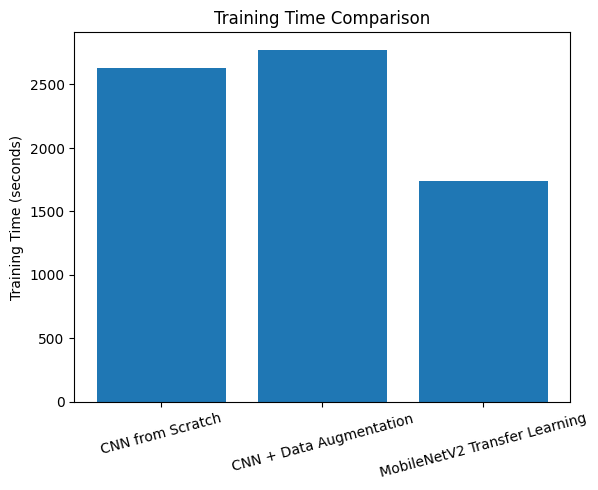

In [46]:
plt.bar(results["Model"],results["Training Time (seconds)"])
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.xticks(rotation=15)

plt.show()

### Identifying the best model

In [47]:
best_model = results.loc[results["Test Accuracy"].idxmax()]
print("Best model based on test accuracy:")
print(best_model)

Best model based on test accuracy:
Model                      CNN + Data Augmentation
Test Accuracy                                0.759
Training Time (seconds)                2772.867829
Name: 1, dtype: object


### Save the best-performing model

In [48]:
best_model_name = best_model["Model"]
if best_model_name == "CNN from Scratch":
    best_model_object = model_cnn
elif best_model_name == "CNN + Data Augmentation":
    best_model_object = model_aug
else:
    best_model_object = model_transfer
best_model_object.save("/content/best_skin_lesion_model.keras")
print("Best model:", best_model_name)
print("Model saved successfully.")

Best model: CNN + Data Augmentation
Model saved successfully.


# Final Conclusion
Three approaches were evaluated on the melanoma skin lesion dataset:
1. CNN trained from scratch.
2. CNN with data augmentation.
3. MobileNetV2 using transfer learning with frozen pre-trained layers.
The models were compared using test accuracy and training time.
The best-performing approach was selected based on the experimental results.
The final model was saved for use in the next stages of the project.

The experiment results were recorded to make the Sprint 2 model comparison
systematic and reproducible.

# Hands-On Lab: Building and Transferring a CNN

### Task 1 — Build and train a small CNN from scratch on an image dataset and record its accuracy

* Built and trained a small CNN from scratch using the melanoma skin cancer image dataset.
* Recorded the test accuracy and training time as a baseline for comparison.

### Task 2 — Add data augmentation and compare the new validation curves to the previous run.

* Added random flipping, rotation, and zoom augmentation to the CNN training pipeline.
* Trained the augmented CNN model.
* Compared the validation curves with the original CNN to evaluate the effect of data augmentation.

### Task 3 — Apply transfer learning with a frozen pre-trained model (e.g. MobileNetV2) and compare accuracy and training time.

* Applied transfer learning using a frozen pre-trained MobileNetV2 model.
* Trained a new classification head on the melanoma skin cancer dataset.
* Compared the transfer learning model's accuracy and training time with the CNN models.

### Task 4 — Document which approach performed best and why, in Markdown

* Compared the CNN from scratch, CNN with data augmentation, and MobileNetV2 transfer learning.
* Identified the best-performing approach based on accuracy and training time.
* Documented why the selected approach performed better than the alternatives.
